In [3]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import precision_score, recall_score, f1_score

set_random_seed = 171

# Load datasets
train_df = pd.read_csv("data/train_dataset.csv")
test_df = pd.read_csv("data/test_dataset.csv")

# Separate features and target
X_train = train_df.drop(columns=['Target_binary'])
y_train = train_df['Target_binary']

X_test = test_df.drop(columns=['Target_binary'])
y_test = test_df['Target_binary']

print("Datasets loaded successfully.")
print("\nTraining shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ratio of non-dropouts to dropouts in training set
scale = (y_train == 0).sum() / (y_train == 1).sum()
print("\nscale_pos_weight (class imbalance ratio):", round(scale, 2))

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=set_random_seed
)

# Cross-validation ONLY on training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=set_random_seed)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_scores = cross_validate(
    xgb_model, X_train, y_train,
    cv=cv,
    scoring=scoring
)

print("\nCross-validation (Training Set)")
print("Precision:", cv_scores["test_precision"].mean())
print("Recall:", cv_scores["test_recall"].mean())
print("F1:", cv_scores["test_f1"].mean())

# Final evaluation on test set
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# print("\nTest Set Performance (25% Unseen Data)")
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall:", recall_score(y_test, y_pred))
# print("F1:", f1_score(y_test, y_pred))

Datasets loaded successfully.

Training shape: (2654, 20)
Test shape: (1107, 20)

scale_pos_weight (class imbalance ratio): 2.12

Cross-validation (Training Set)
Precision: 0.8082245630130451
Recall: 0.7758307533539732
F1: 0.7916154768997068


In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    matthews_corrcoef
)

print("\nTest Set Performance (25% Unseen Data)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Test Set Performance (25% Unseen Data)
Accuracy: 0.8599819331526649
Precision: 0.7913043478260869
Recall: 0.7668539325842697
F1: 0.7788873038516405
MCC: 0.6766571108959653
[[679  72]
 [ 83 273]]


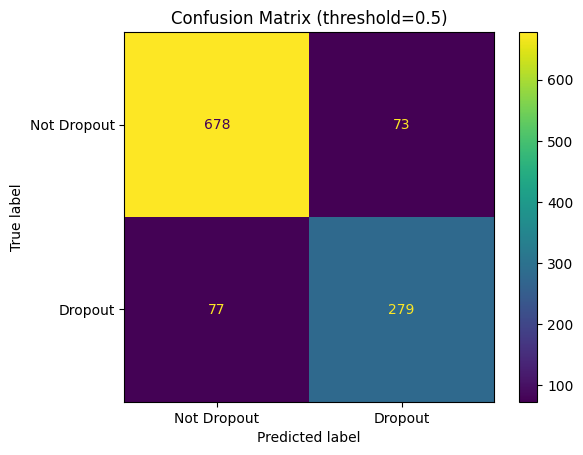


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

 Not Dropout       0.90      0.90      0.90       751
     Dropout       0.79      0.78      0.79       356

    accuracy                           0.86      1107
   macro avg       0.85      0.84      0.84      1107
weighted avg       0.86      0.86      0.86      1107



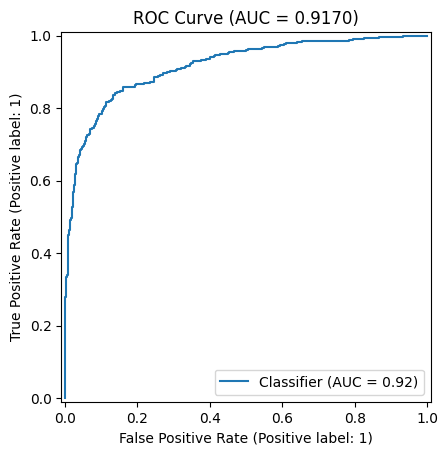

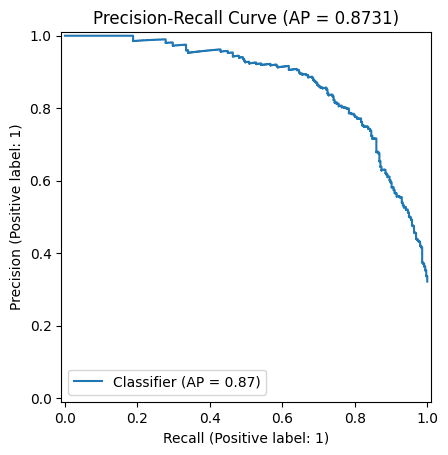


=== Additional Metrics (Test Set) ===
ROC AUC:              0.9170
Average Precision:    0.8731
Balanced Accuracy:    0.8433


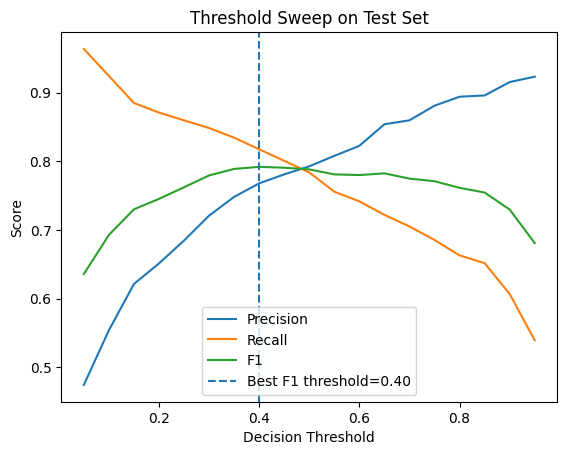


Best F1 on test set occurs at threshold ≈ 0.40 with F1 = 0.7918


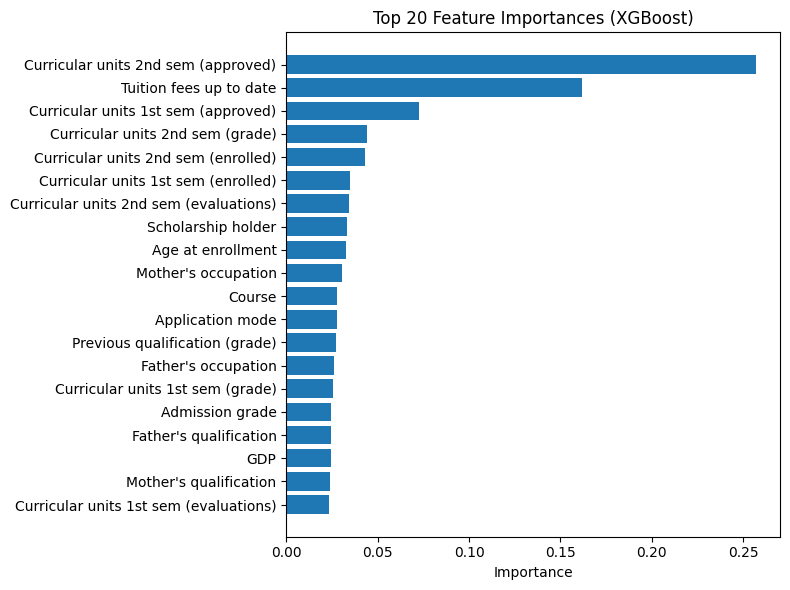

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
)

# Probabilities / scores (needed for ROC / PR / calibration metrics)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Confusion Matrix (default threshold = 0.5)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Dropout", "Dropout"])
disp.plot(values_format="d")
plt.title("Confusion Matrix (threshold=0.5)")
plt.show()

# Classification report (precision/recall/f1 per class)
print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred, target_names=["Not Dropout", "Dropout"]))

# ROC Curve + AUC
roc_auc = roc_auc_score(y_test, y_proba)
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

# Precision-Recall Curve + Average Precision
avg_prec = average_precision_score(y_test, y_proba)
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title(f"Precision-Recall Curve (AP = {avg_prec:.4f})")
plt.show()

# Additional summary metrics
print("\n=== Additional Metrics (Test Set) ===")
print(f"ROC AUC:              {roc_auc:.4f}")
print(f"Average Precision:    {avg_prec:.4f}")
print(f"Balanced Accuracy:    {balanced_accuracy_score(y_test, y_pred):.4f}")

# Threshold sweep: see how precision/recall/f1 change with cutoff
thresholds = np.linspace(0.05, 0.95, 19)

def prf_at_threshold(t):
    pred_t = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred_t, labels=[0, 1])
    tn, fp, fn, tp = cm_t.ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return precision, recall, f1

precisions, recalls, f1s = [], [], []
for t in thresholds:
    p, r, f = prf_at_threshold(t)
    precisions.append(p); recalls.append(r); f1s.append(f)

best_idx = int(np.argmax(f1s))
best_t = float(thresholds[best_idx])

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1")
plt.axvline(best_t, linestyle="--", label=f"Best F1 threshold={best_t:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Sweep on Test Set")
plt.legend()
plt.show()

print(f"\nBest F1 on test set occurs at threshold ≈ {best_t:.2f} with F1 = {f1s[best_idx]:.4f}")

# Feature importance
importances = xgb_model.feature_importances_
order = np.argsort(importances)[::-1]

top_k = min(20, len(importances))
plt.figure(figsize=(8, 6))
plt.barh(range(top_k), importances[order][:top_k][::-1])
plt.yticks(range(top_k), [X_test.columns[i] for i in order[:top_k]][::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_k} Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()